## 13장 합성곱 신경망을 사용한 이미지 분류

### 1. 패션 MNIST 데이터 불러오기

In [11]:
# 필요한 라이브러리를 임포트한다.
from tensorflow import keras
from sklearn.model_selection import train_test_split

# 패션 MNIST 데이터셋을 로드한다.
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

# 넘파이 reshape()를 사용해 전체 배열 차원을 그대로 유지하면서 마지막에 차원을 추가한다.
# 훈련데이터를 0~1 사이의 값으로 정규화한다.
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

# 훈련세트와 검증세트를 분리한다.
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

### 2. 합성곱 신경망 만들기

2.1 첫번째 합성곱 - 풀링층 추가

In [12]:
# 신경망 객체를 생성한다.
model = keras.Sequential()

In [13]:
# 신경망 모델에 합성곱 층을 추가한다.
# 필터의 개수는 32, 커널의 크기는 (3,3), 활성화점수는 렐루함수, 패딩은 세임패딩
# 입력크기는 (28, 28, 1)으로 지정한다.
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same',
                              input_shape=(28,28,1)))

In [14]:
# 신경망 모델에 풀링 층을 추가한다.
# 최대 풀링을 사용하며 풀링 크기는 (2, 2)로 지정한다.
model.add(keras.layers.MaxPooling2D(2))

2.2 두번째 합성곱 - 풀링층 추가

In [15]:
# 신경망 모델에 필터의 개수가 64개인 합성곱 층을 추가한다.
# 필터의 개수는 64, 커널의 크기는 (3, 3), 활성화함수는 렐루함수, 패딩은 세임패딩을 지정한다.
model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))

# 신경망 모델에 풀링 층을 추가한다.
# 최대 풀링을 사용하며 풀링 크기는 (2, 2)로 지정한다.
model.add(keras.layers.MaxPooling2D(2))

2.3 세번째 완전연결층

In [16]:
# Flatten 층을 추가한다.
# Flatten 층은 3차원 특성맵을 일렬로 펼친다.
model.add(keras.layers.Flatten())

# 학습, 예측, 평가 계산을 위한 밀집층(은닉층)을 추가한다.
#100개의 뉴런을 사용하고 활성화 함수는 렐루함수를 사용한다.
model.add(keras.layers.Dense(100, activation='relu'))

# 과대적합을 막아 성능을 개선하기 위한 드롭아웃층을 추가한다.
model.add(keras.layers.Dropout(0.4))

# 클래스 분류 확률 계산을 위한 밀집층(출력층)을 추가한다.
# 10개의 뉴런을 사용하고 활성화 함수는 소프트맥스 함수를 사용한다.
model.add(keras.layers.Dense(10, activation='softmax'))

In [17]:
# summary()으로 신경망 모델의 정보를 출력한다.
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0         
                                                                 
 dense_2 (Dense)             (None, 100)              

2.4 신경망 구조를 그림으로 출력

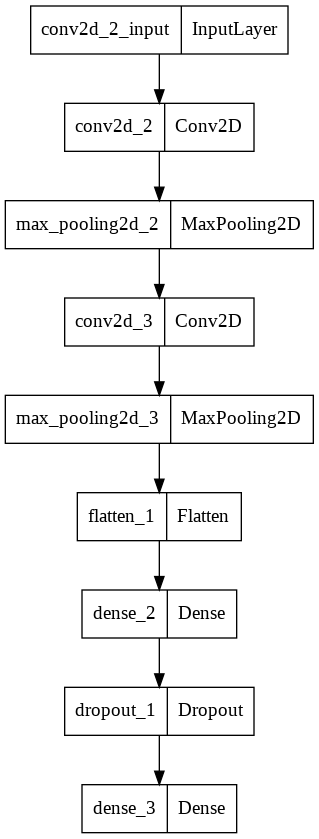

In [18]:
# plot_model()으로 model 신경망 구조를 그림으로 출력한다.
keras.utils.plot_model(model)

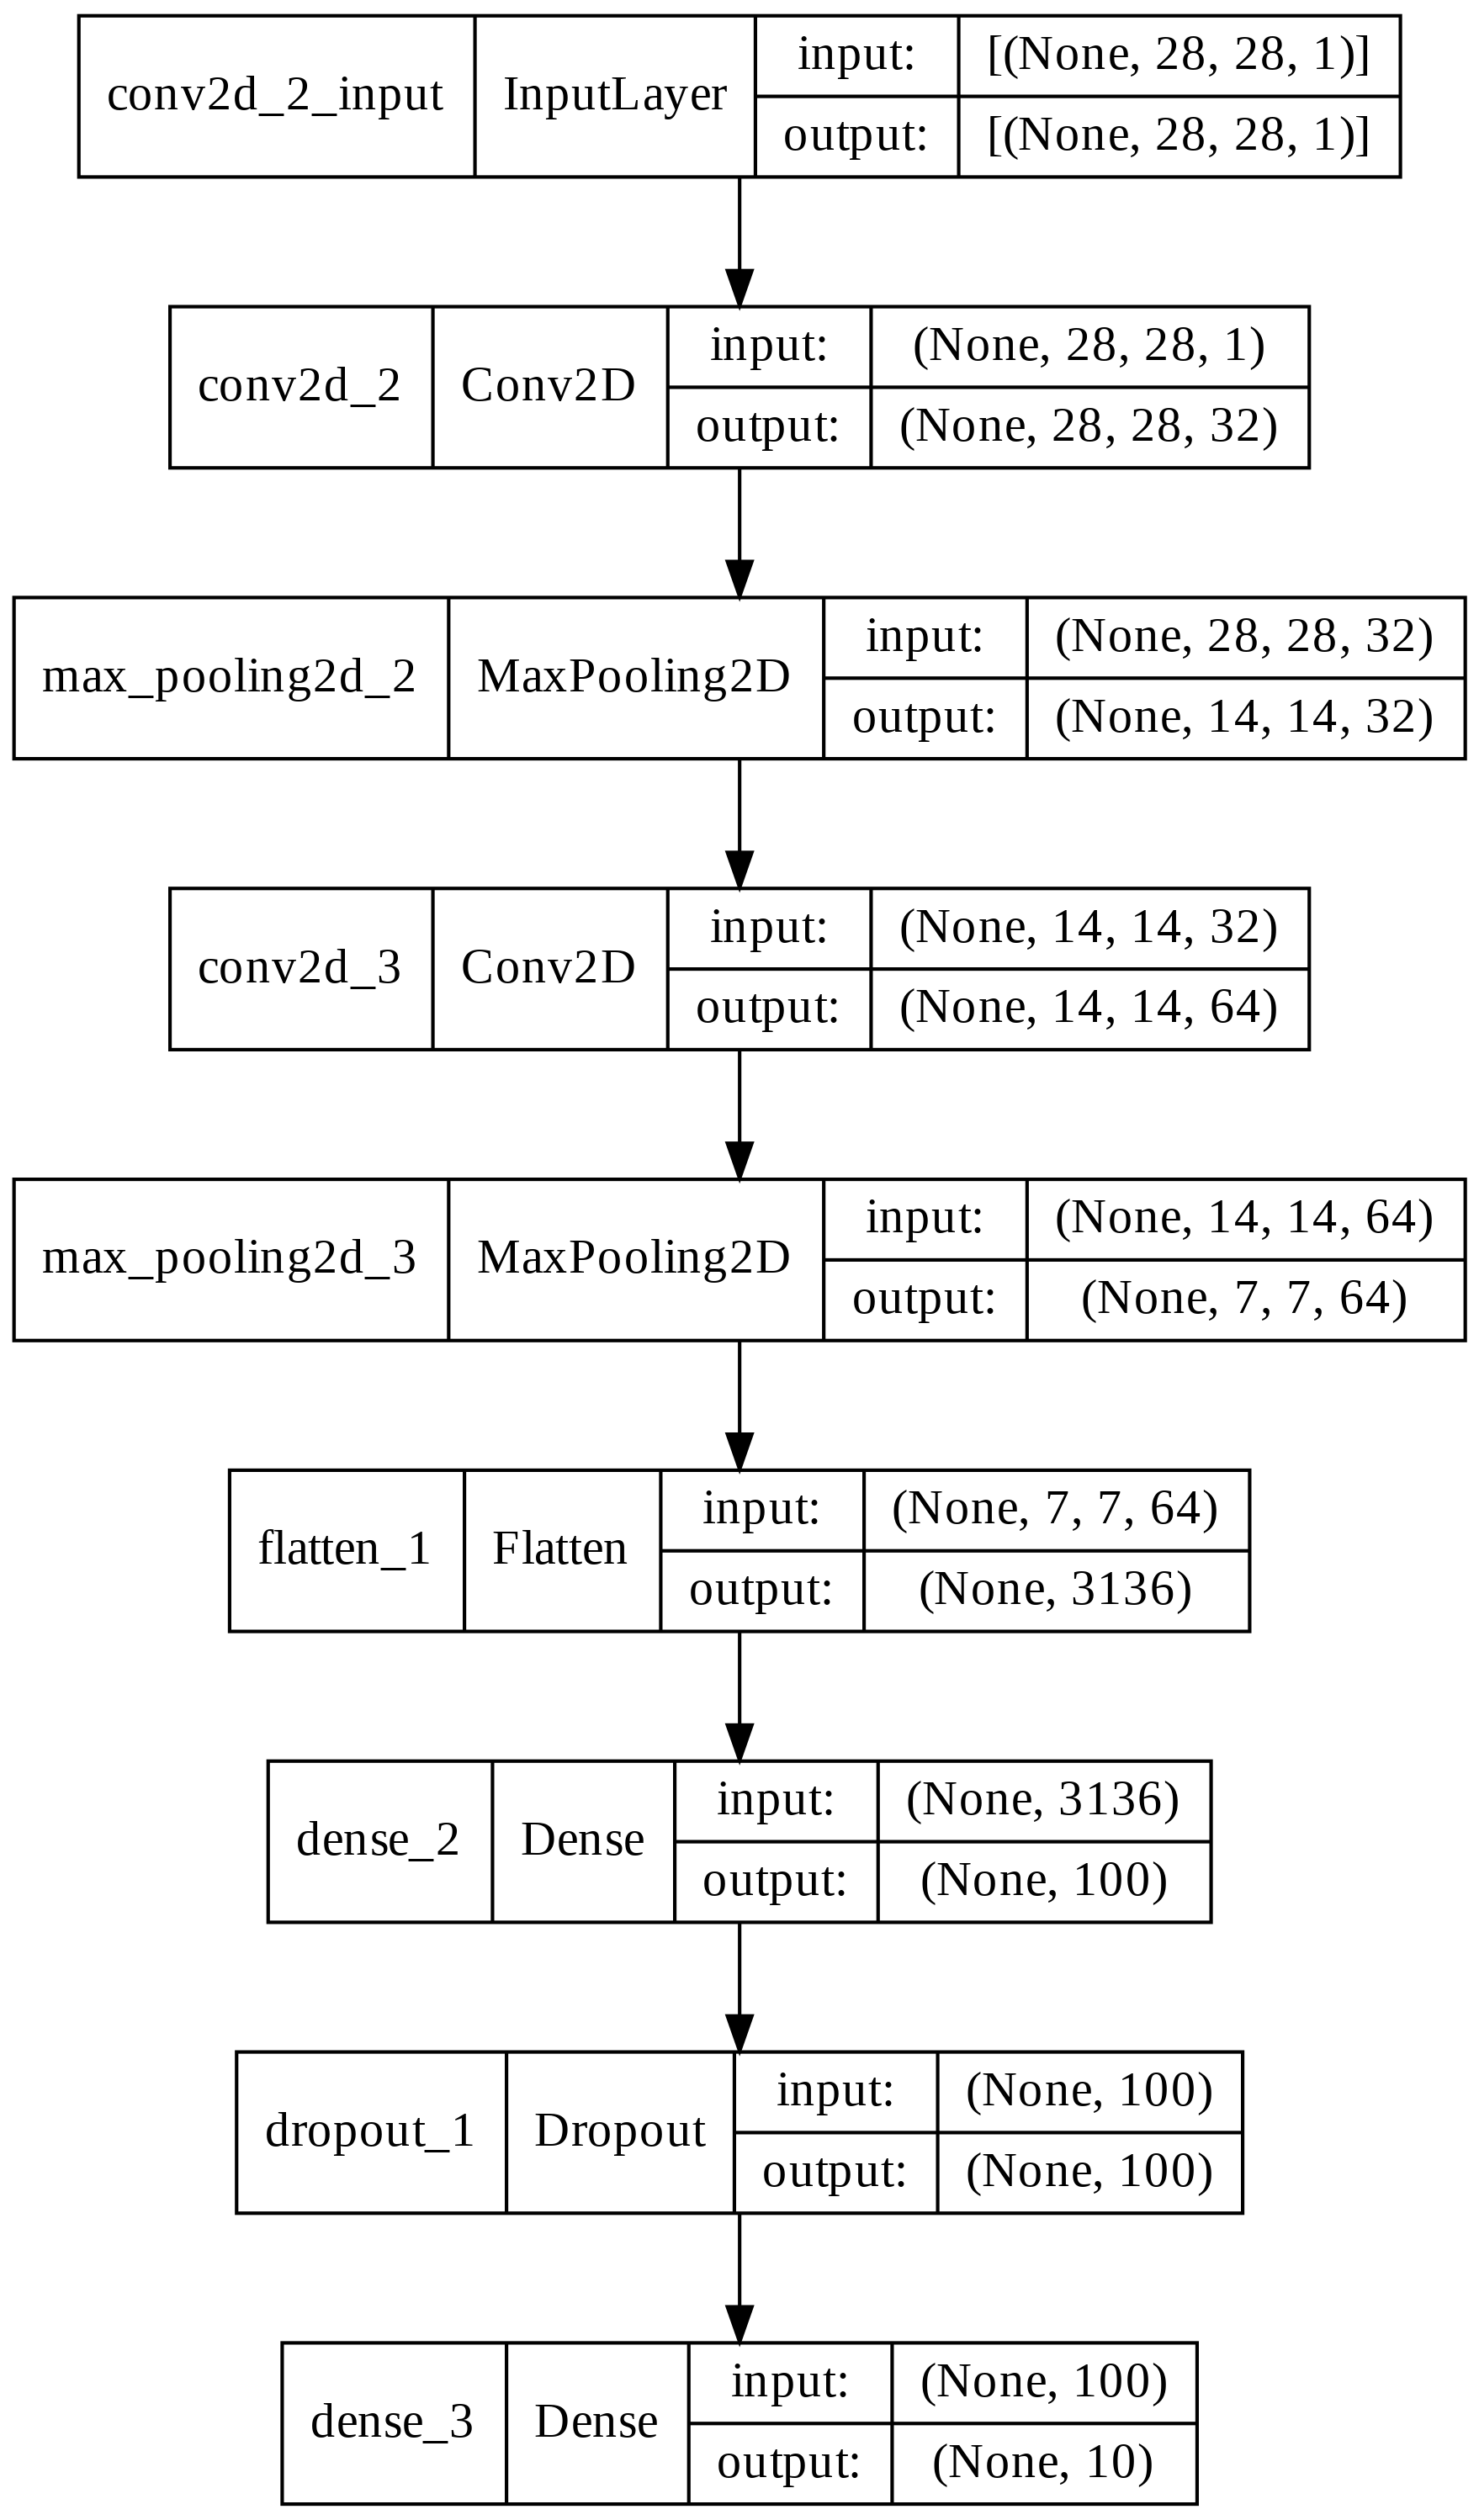

In [19]:
# show_shapes=True는 입력과 출력 크기를 함께 표시한다.
keras.utils.plot_model(model, show_shapes=True, to_file='cnn-architecture.png', dpi=300)

### 3. 모델 컴파일과 훈련

3.1 콜백 객체 지정

In [20]:
# 모델 훈련전에 옵티마이저, 손실함수, 정확도를 지정한다.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')

# ModelCheckpoin 콜백은 최상의 검증점수(가장 낮은 검증 손실값)를 만드는 모델을 저장한다.
# 콜백은 훈련과정 중간에 어떤 작업을 수행 할 수 있게 하는 객체를 의미한다.
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.h5')

# 조기종료를 위한 EarlyStopping 콜백 객체를 만든다.
# patience=2은 2번 연속 검증 손실값이 향상되지 않으면 훈련을 중지한다.
# restore_best_weights=True는 가장 낮은 검증 손실값을 낸 모델 파라미터로 되돌린다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

# fit()의 callbacks 매개변수에 콜백객체들의 리스트를 전달한다.
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 [==============================] - 65s 43ms/step - loss: 0.5164 - accuracy: 0.8158 - val_loss: 0.3220 - val_accuracy: 0.8826
Epoch 2/20
1500/1500 [==============================] - 62s 41ms/step - loss: 0.3379 - accuracy: 0.8792 - val_loss: 0.2735 - val_accuracy: 0.8984
Epoch 3/20
1500/1500 [==============================] - 62s 41ms/step - loss: 0.2864 - accuracy: 0.8958 - val_loss: 0.2478 - val_accuracy: 0.9069
Epoch 4/20
1500/1500 [==============================] - 62s 41ms/step - loss: 0.2580 - accuracy: 0.9068 - val_loss: 0.2298 - val_accuracy: 0.9136
Epoch 5/20
1500/1500 [==============================] - 62s 41ms/step - loss: 0.2307 - accuracy: 0.9157 - val_loss: 0.2270 - val_accuracy: 0.9158
Epoch 6/20
1500/1500 [==============================] - 61s 41ms/step - loss: 0.2123 - accuracy: 0.9218 - val_loss: 0.2107 - val_accuracy: 0.9191
Epoch 7/20
1500/1500 [==============================] - 62s 41ms/step - loss: 0.1941 - accuracy: 0.9279 - val_loss: 0.2152 -